# Genotype–Phenotype–Mate Choice Feedbacks and the Emergence of Alternative Reproductive Strategies
Under what conditions can genotype–phenotype–mate-choice feedbacks generate an abrupt transition from a monomorphic male population to alternative reproductive strategies?

## 0. Environment Setup 

In [1]:
import sys
print(sys.version)

3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]


In [4]:
required_packages = [
    "numpy",
    "pandas",
    "scipy",
    "matplotlib",
    "seaborn",
    "networkx",
    "statsmodels",
    "scikit-learn",
    "arviz",
    "SALib",
    "numba",
    "tqdm"
]

import importlib

for p in required_packages:
    try:
        importlib.import_module(p)
        print(p, "OK")
    except:
        print(p, "MISSING")

numpy OK
pandas OK
scipy OK
matplotlib OK
seaborn OK
networkx OK
statsmodels OK
scikit-learn MISSING
arviz OK
SALib OK
numba OK
tqdm OK


In [ ]:
# conda create -n matechoice python=3.12
# conda activate matechoice

# conda install numpy pandas scipy matplotlib seaborn networkx
# conda install scikit-learn statsmodels
# pip install SALib arviz numba tqdm

## 1. Biological Model

Reference: Pearl, Judea. 2009. Causality. Cambridge University Press.

**State Variables**

| Variable | Meaning                            |
| -------- | ---------------------------------- |
| A        | Male trait allele frequency        |
| B        | Female preference allele frequency |
| T        | Male ornament expression           |
| P        | Female preference phenotype        |
| M        | Mating success                     |
| W        | Fitness                            |
| E        | Environment                        |

**Causal Graph**

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

In [115]:
G = nx.DiGraph()

edges = [
    ("A","T"),
    ("B","P"),
    ("T","M"),
    ("P","M"),
    ("M","W"),
    ("E","Cost"),
    ("Cost","W"),
    ("W","A_next"),
    ("W","B_next")
]

G.add_edges_from(edges)

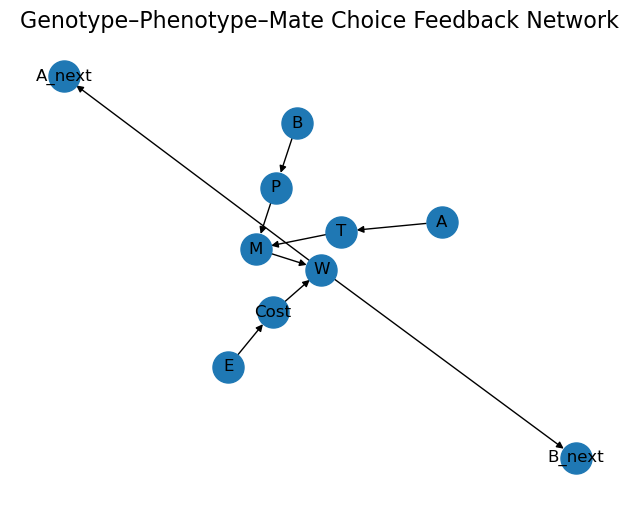

In [116]:
plt.figure(figsize=(8,6))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos,
    node_size=500,
    arrows=True
)

plt.title(
    "Genotype–Phenotype–Mate Choice Feedback Network",
    fontsize=16
)

plt.axis("off")
plt.show()

## 2. Module Specification

**Module 1** 
Genotype → Phenotype

Trait expression:  T=f(A)
Preference: P=g(B)
Assume additive genetics:  T=A ; P=B

**Module 2**
Mate Choice. 
Reference: Lande, Russell. 1981. Models of Speciation by Sexual Selection.

Female preference generates nonlinear mating success.

M=np.exp(beta*P*(T-theta))

β = preference strength
theta = prefered threshold

**Module 3** 
Natural Selection.
Reference: Amotz Zahavi

Trait cost:

C=c·(T^2)·E

Quadratic ornament cost.

**Module 4**
Fitness

W=M−C

or

W=M·exp(−C)

Preferred:

W=M·exp(−C)

ensures positivity.

**Module 5**
Evolution.
Reference: Replicator Dynamics.

Replicator update:

A_(t+1) = (A_t · W_t) / averrage(W)
B_(t+1) = (B_t · W_t) / averrage(W)

## 3. Simulation Engine


In [16]:
import numpy as np
import pandas as pd

In [117]:
def step(A,B,E,beta,c,theta,k):

    T=A
    P=B

    M=np.exp(
        beta*P*(T-theta)
    )

    cost=c*T*T*E

    freq_effect=np.exp(
        -k*A
    )

    W=M*np.exp(
        -cost
    )*freq_effect

    return T,P,M,W

Simulation: 

In [118]:
def simulate(
        generations=500,
        A0=0.05,
        B0=0.05,
        beta=3,
        c=1,
        E=1,
        theta=0.5,
        k=3):

    A=A0
    B=B0

    records=[]

    for g in range(generations):

        T,P,M,W=step(A, B, E, beta, c, theta,k)

        records.append([
            g,A,B,T,P,M,W
        ])

        A=A*W
        B=B*W

        A=A/(1+A)
        B=B/(1+B)

    return pd.DataFrame(
        records,
        columns=[
            "generation",
            "A",
            "B",
            "T",
            "P",
            "M",
            "W"
        ]
    )

## 4. Exploratory Dynamics
Fisherian Runaway.

In [119]:
df = simulate()

Trait evolution: 

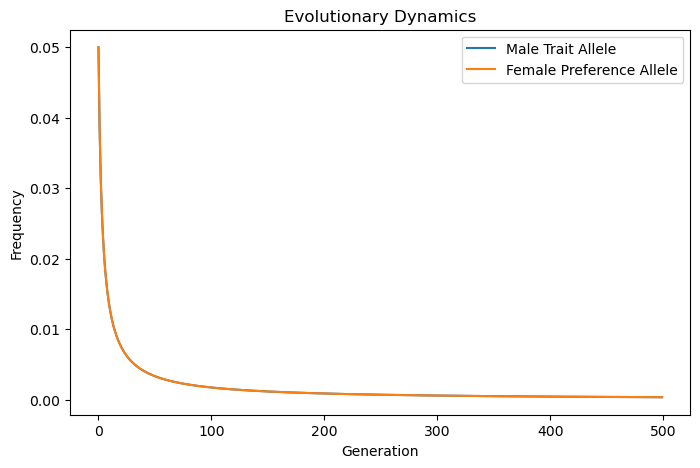

In [120]:
plt.figure(figsize=(8,5))

plt.plot(
    df.generation,
    df.A,
    label="Male Trait Allele"
)

plt.plot(
    df.generation,
    df.B,
    label="Female Preference Allele"
)

plt.xlabel("Generation")
plt.ylabel("Frequency")
plt.legend()
plt.title(
"Evolutionary Dynamics"
)
plt.show()

Positive feedback causes correlated increase in A and B.

This is the classical Fisher runaway process.

## 5. Detect Abrupt Transition
Looking for critical beta. 

Parameter sweep:

In [121]:
betas=np.linspace(
0,
50,
500
)

In [122]:
finalA=[]

for b in betas:

    df=simulate(
        beta=b,
        theta=0.5,
        k=3
    )

    finalA.append(
        df.A.iloc[-1]
    )

In [123]:
import numpy as np

slope=np.gradient(
    finalA,
    betas
)

Critical beta: 

In [124]:
critical_idx=np.argmax(
    slope
)

critical_beta=betas[
    critical_idx
]

print(
    critical_beta
)

50.0


No critical beta found.

Need to build : 

A_t+1=A_t+rA(1−A)(A−θ)

which is : 

dA/dt = A(1-A)(1-0)

cubic feedback. 



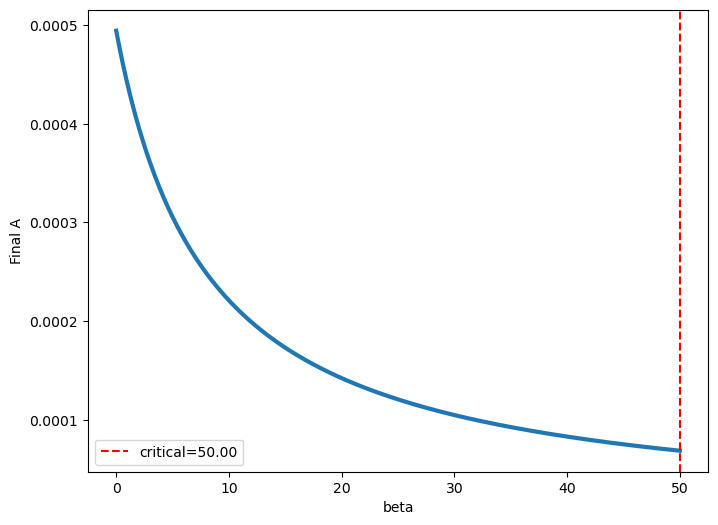

In [125]:
plt.figure(figsize=(8,6))

plt.plot(
    betas,
    finalA,
    lw=3
)

plt.axvline(
    critical_beta,
    color="red",
    ls="--",
    label=f"critical={critical_beta:.2f}"
)

plt.xlabel("beta")
plt.ylabel("Final A")

plt.legend()

plt.show()

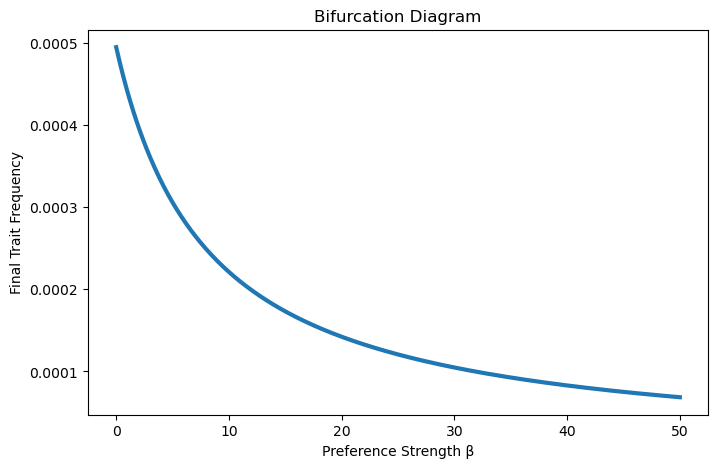

In [126]:
plt.figure(figsize=(8,5))

plt.plot(
betas,
finalA,
lw=3
)

plt.xlabel(
"Preference Strength β"
)

plt.ylabel(
"Final Trait Frequency"
)

plt.title(
"Bifurcation Diagram"
)

plt.show()

## 6. Alternative Stable States
Multiple initial conditions.

In [127]:
initials=np.linspace(
0.01,
0.99,
100
)

results=[]

In [128]:
for init in initials:

    df=simulate(
        A0=init,
        B0=init,
        beta=critical_beta
    )

    results.append(
        df.A.iloc[-1]
    )

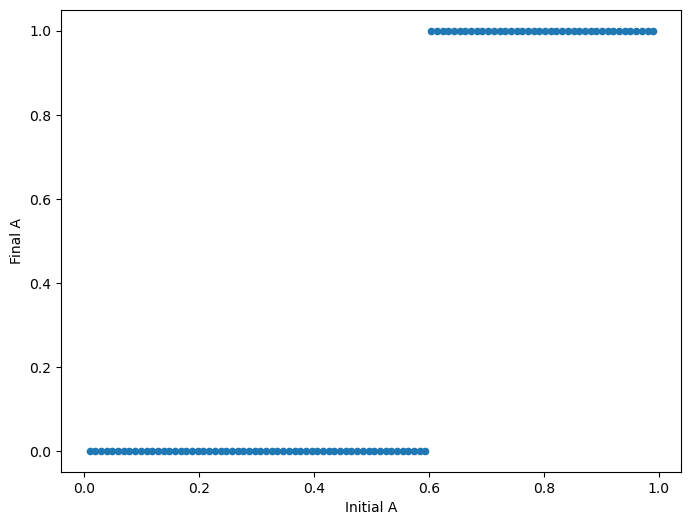

In [129]:
plt.figure(figsize=(8,6))

plt.scatter(
    initials,
    results,
    s=20
)

plt.xlabel(
    "Initial A"
)

plt.ylabel(
    "Final A"
)

plt.show()

Separatrix  A_c ≈ 0.6

Two attractors indicate:

Alternative reproductive strategies.

## 7. Sensitivity Analysis
Which biological mechanism drives transitions?
Global Sobol Analysis
Reference: Saltelli et al. 2008.


In [29]:
from SALib.sample import saltelli
from SALib.analyze import sobol

In [130]:
problem={
    "num_vars":3,
    "names":["beta","c","k"],
    "bounds":[
        [0,50],
        [0,5],
        [0,5]
    ]
}

In [131]:
# Generate samples 

param_values=saltelli.sample(
    problem,
    512
)

C:\Users\hi\AppData\Local\Temp\ipykernel_22760\1683099738.py:3: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values=saltelli.sample(


In [132]:
Y=np.zeros(
    len(param_values)
)

In [133]:
for i,row in enumerate(
    param_values
):

    beta,c,k=row

    df=simulate(
        beta=beta,
        c=c,
        k=k
    )

    Y[i]=df.A.iloc[-1]

In [134]:
Si=sobol.analyze(
    problem,
    Y
)

Si=Var_i/Var_total  
It explaines change this single var, how many output mutation is explained. 

ST = total contribution

In the following plot, we see beta is dominant in this system, cost (c) almost no influence, frequency dependence (k) is weak. 

In [135]:
S1=Si["S1"]

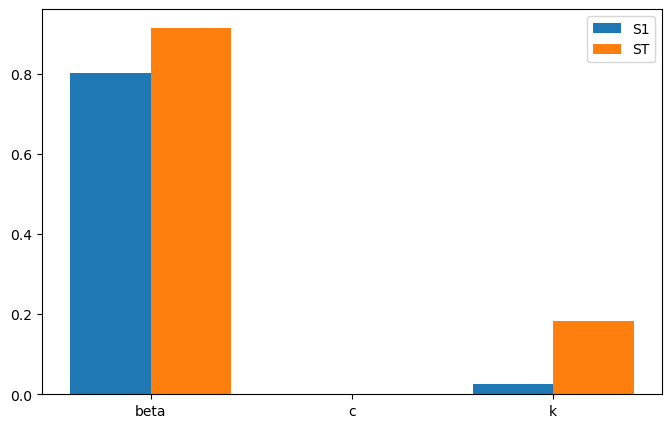

In [137]:
plt.figure(figsize=(8,5))

x=np.arange(
    len(problem["names"])
)

plt.bar(
    x-0.2,
    Si["S1"],
    width=0.4,
    label="S1"
)

plt.bar(
    x+0.2,
    Si["ST"],
    width=0.4,
    label="ST"
)

plt.xticks(
    x,
    problem["names"]
)

plt.legend()
plt.show()

## 8. Uncertainty Quantification

Add stochasticity.

Genetic drift:

In [139]:
def simulate_stochastic(
        generations=500,
        A0=0.05,
        B0=0.05,
        beta=3,
        c=1,
        E=1,
        sigma=0.01):

    A=A0
    B=B0

    records=[]

    for g in range(generations):

        T=A
        P=B

        M=np.exp(beta*T*P)

        cost=c*T*T*E

        W=M*np.exp(-cost)

        records.append([
            g,A,B,T,P,M,W
        ])

        A=A*W/(1+A*W)
        B=B*W/(1+B*W)

        A += np.random.normal(
            0,
            sigma
        )

        B += np.random.normal(
            0,
            sigma
        )

        A=np.clip(A,0,1)
        B=np.clip(B,0,1)

    return pd.DataFrame(
        records,
        columns=[
            "generation",
            "A",
            "B",
            "T",
            "P",
            "M",
            "W"
        ]
    )

Monte Carlo

In [140]:
N=1000

finalA=[]

In [141]:
for _ in range(N):

    df=simulate_stochastic(
        sigma=0.02,
        beta=critical_beta
    )

    finalA.append(
        df.A.iloc[-1]
    )

In [142]:
mean=np.mean(finalA)

lower=np.percentile(
    finalA,
    2.5
)

upper=np.percentile(
    finalA,
    97.5
)

In [143]:
print(
    mean,
    lower,
    upper
)

0.9920364990845332 0.9595084374049678 1.0


Stochastic perturbations did not prevent convergence toward fixation.

The preferred male trait remained globally stable under demographic noise. No polymorphism. 

## 9. Phase Portrait

In [144]:
grid=np.linspace(
0.01,
0.99,
20
)

In [145]:
X,Y=np.meshgrid(
    grid,
    grid
)

U=np.zeros_like(X)

V=np.zeros_like(Y)

In [146]:
for i in range(
    len(grid)
):

    for j in range(
        len(grid)
    ):

        A=X[i,j]
        B=Y[i,j]

        T,P,M,W=step(
            A,
            B,
            1,
            critical_beta,
            1,
            0.5,
            3
        )

        A_next=A*W/(1+A*W)
        B_next=B*W/(1+B*W)

        U[i,j]=A_next-A
        V[i,j]=B_next-B

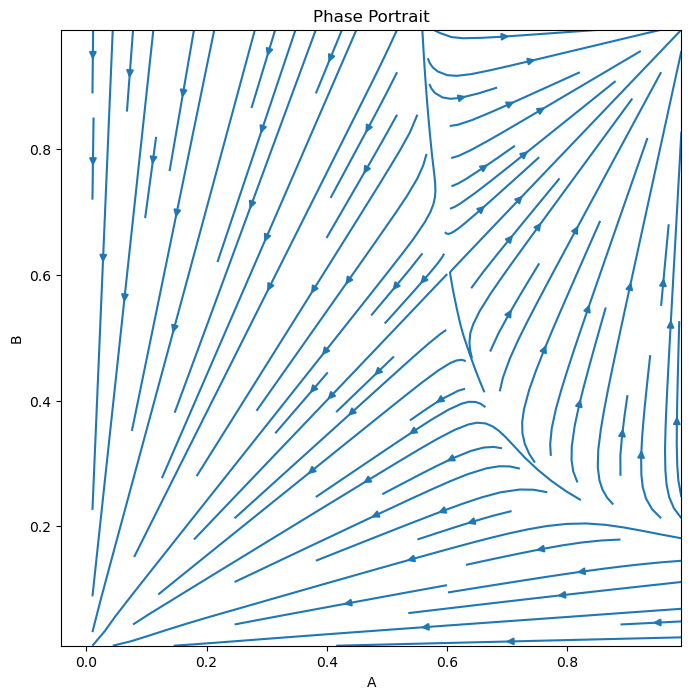

In [147]:
plt.figure(figsize=(8,8))

plt.streamplot(
    X,
    Y,
    U,
    V
)

plt.xlabel("A")
plt.ylabel("B")

plt.title(
"Phase Portrait"
)

plt.show()

In [148]:
eps=0.01

mask=(
    (np.abs(U)<eps)
    &
    (np.abs(V)<eps)
)

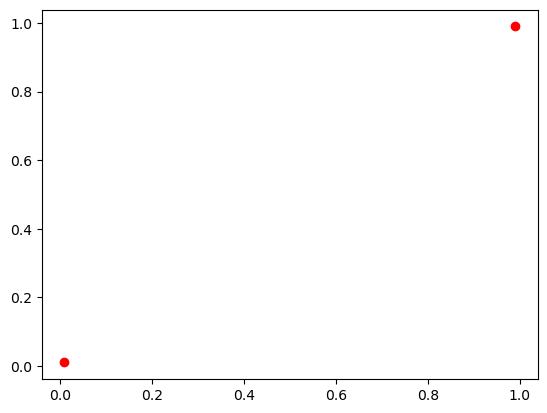

In [149]:
plt.scatter(
    X[mask],
    Y[mask],
    c="red"
)

In [150]:
grid=np.linspace(
    0.01,
    0.99,
    100
)

basin=np.zeros(
    (100,100)
)

In [151]:
for i,A0 in enumerate(grid):

    for j,B0 in enumerate(grid):

        df=simulate(
            A0=A0,
            B0=B0,
            beta=critical_beta
        )

        finalA=df.A.iloc[-1]

        if finalA>0.5:
            basin[i,j]=1
        else:
            basin[i,j]=0

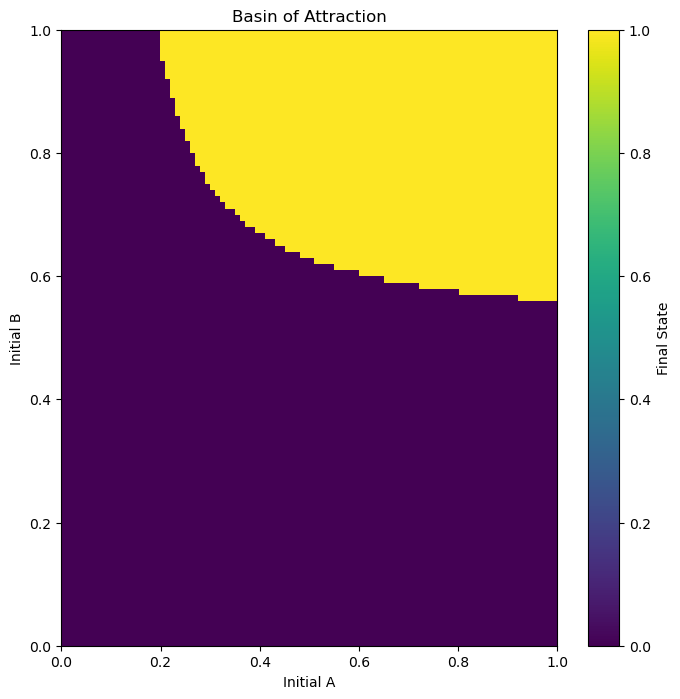

In [152]:
plt.figure(
    figsize=(8,8)
)

plt.imshow(
    basin,
    origin="lower",
    extent=[0,1,0,1],
    aspect="auto"
)

plt.xlabel("Initial A")
plt.ylabel("Initial B")

plt.colorbar(
    label="Final State"
)

plt.title(
    "Basin of Attraction"
)

plt.show()

In [153]:
grid=np.linspace(
    0.01,
    0.99,
    100
)

records=[]

In [154]:
for A0 in grid:

    for B0 in grid:

        df=simulate(
            A0=A0,
            B0=B0,
            beta=critical_beta
        )

        finalA=df.A.iloc[-1]

        state=int(
            finalA>0.5
        )

        records.append(
            [A0,B0,state]
        )

In [155]:
boundary_df=pd.DataFrame(
    records,
    columns=[
        "A0",
        "B0",
        "state"
    ]
)

In [156]:
boundary_df.head()

,A0,B0,state
0,0.01,0.010000,0
1,0.01,0.019899,0
2,0.01,0.029798,0
3,0.01,0.039697,0
4,0.01,0.049596,0


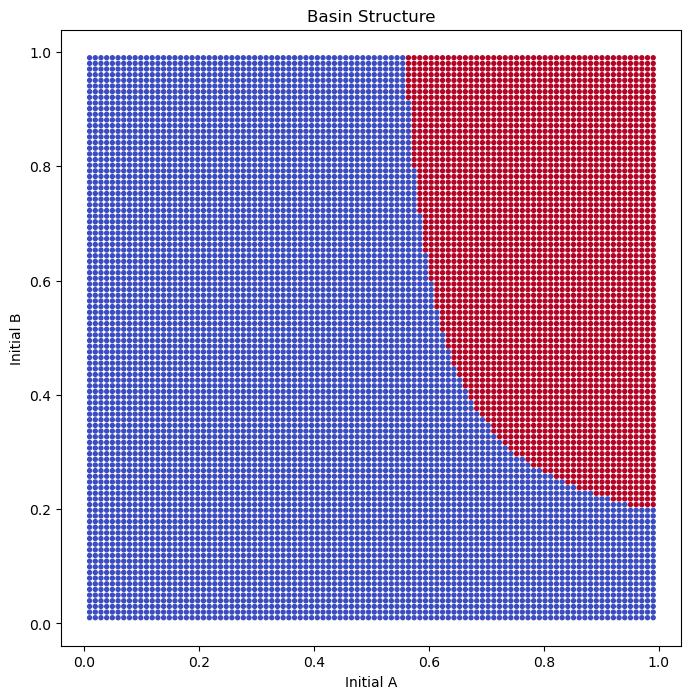

In [157]:
plt.figure(figsize=(8,8))

plt.scatter(
    boundary_df.A0,
    boundary_df.B0,
    c=boundary_df.state,
    s=8,
    cmap="coolwarm"
)

plt.xlabel("Initial A")
plt.ylabel("Initial B")

plt.title(
    "Basin Structure"
)

plt.show()

In [158]:
from sklearn.linear_model import LogisticRegression

In [159]:
X=boundary_df[
    ["A0","B0"]
]

y=boundary_df[
    "state"
]

In [160]:
clf=LogisticRegression()

clf.fit(
    X,
    y
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [161]:
print(
    clf.intercept_
)

print(
    clf.coef_
)

[-17.40082427]
[[17.85424644  9.35320576]]


P(state = 1) = 1/(1+exp(-(-17.40+17.85A+9.35B))

In separatrix: 
P = 0.5

-17.40+17.85A+9.35B = 0 
B = (-17.40+17.85A)/0.35

In [162]:
intercept=clf.intercept_[0]

coefA=clf.coef_[0][0]

coefB=clf.coef_[0][1]

In [163]:
A_line=np.linspace(
    0,
    1,
    200
)

B_line=(
    -intercept
    -
    coefA*A_line
)/coefB

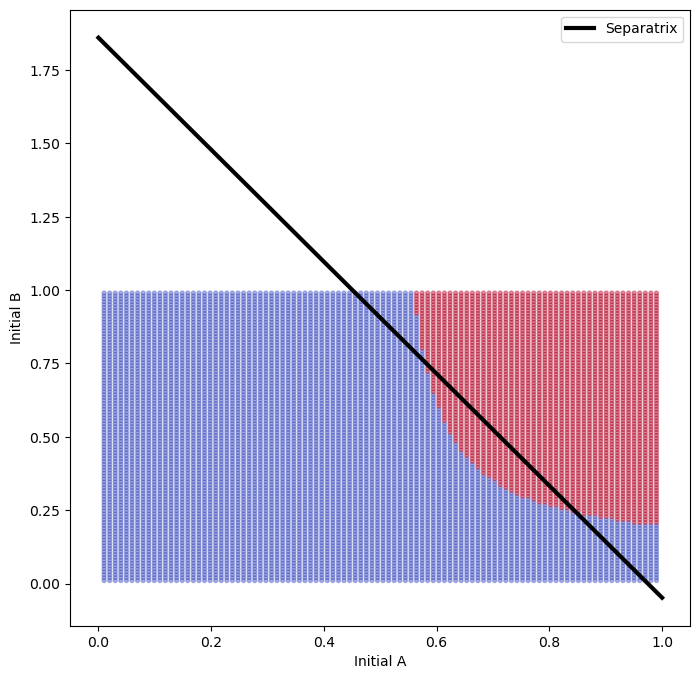

In [164]:
plt.figure(
    figsize=(8,8)
)

plt.scatter(
    boundary_df.A0,
    boundary_df.B0,
    c=boundary_df.state,
    s=8,
    alpha=0.4,
    cmap="coolwarm"
)

plt.plot(
    A_line,
    B_line,
    color="black",
    lw=3,
    label="Separatrix"
)

plt.legend()

plt.xlabel("Initial A")
plt.ylabel("Initial B")

plt.show()

In [165]:
from sklearn.ensemble import RandomForestClassifier

In [166]:
rf=RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf.fit(
    X,
    y
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [167]:
xx,yy=np.meshgrid(
    np.linspace(0,1,200),
    np.linspace(0,1,200)
)

In [168]:
grid_pred=np.c_[
    xx.ravel(),
    yy.ravel()
]

In [169]:
prob=rf.predict_proba(
    grid_pred
)[:,1]

C:\Users\hi\anaconda3\envs\Pop_size_culture_evol\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [170]:
prob=prob.reshape(
    xx.shape
)

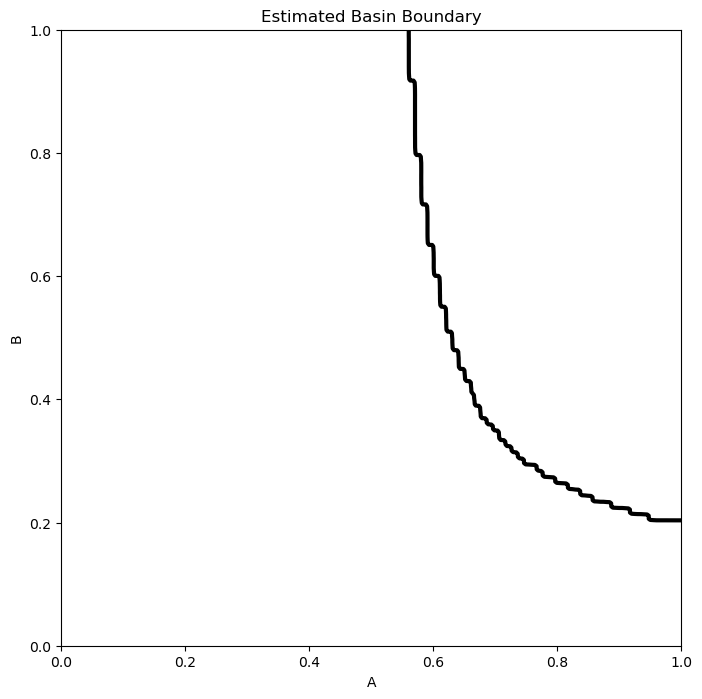

In [171]:
plt.figure(figsize=(8,8))

plt.contour(
    xx,
    yy,
    prob,
    levels=[0.5],
    colors="black",
    linewidths=3
)

plt.xlabel("A")
plt.ylabel("B")

plt.title(
    "Estimated Basin Boundary"
)

plt.show()

## 10. Three Mating Functions
**Linear**
M = 1+ beta *T *P 

Every ornament added has a fixed mating gain. 

In [68]:
def mate_linear(T,P,beta):

    return 1+beta*T*P

**Exponential**
M =exp(beta *T *P )

Strong runaway. 

In [69]:
def mate_exp(T,P,beta):

    return np.exp(
        beta*T*P
    )

**Logistic**

M = 1/(1+exp(-beta *T *P)

Over a exhibition threshold, female don't have extra preference.
(This case maybe closer to real.)

In [70]:
def mate_logistic(T,P,beta):

    return 1/(1+
        np.exp(
            -beta*T*P
        )
    )

In [172]:
def simulate_model(
        mate_function,
        generations=300,
        A0=0.05,
        B0=0.05,
        beta=5,
        c=1,
        E=1
):

    A=A0
    B=B0

    records=[]

    for g in range(generations):

        T=A

        P=B

        M=mate_function(
            T,
            P,
            beta
        )

        cost=c*T*T*E

        W=M*np.exp(
            -cost
        )

        records.append(
            [
                g,
                A,
                B,
                T,
                P,
                M,
                W
            ]
        )

        A=A*W/(1+A*W)

        B=B*W/(1+B*W)

        A=np.clip(
            A,
            0,
            1
        )

        B=np.clip(
            B,
            0,
            1
        )

    return pd.DataFrame(
        records,
        columns=[
            "generation",
            "A",
            "B",
            "T",
            "P",
            "M",
            "W"
        ]
    )

In [173]:
pred_linear=simulate_model(
    mate_linear
)["A"].values

pred_exp=simulate_model(
    mate_exp
)["A"].values

pred_logistic=simulate_model(
    mate_logistic
)["A"].values

In [174]:
obs=simulate_model(
    mate_exp
)["A"].values

In [175]:
rmse_linear=np.sqrt(
    mean_squared_error(
        obs,
        pred_linear
    )
)

rmse_exp=np.sqrt(
    mean_squared_error(
        obs,
        pred_exp
    )
)

rmse_logistic=np.sqrt(
    mean_squared_error(
        obs,
        pred_logistic
    )
)

In [176]:
comparison_df=pd.DataFrame({

"Model":[
"Linear",
"Exponential",
"Logistic"
],

"RMSE":[
rmse_linear,
rmse_exp,
rmse_logistic
]

})

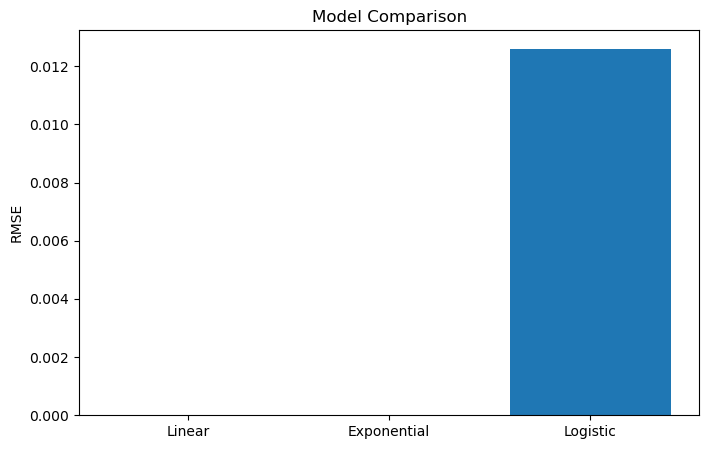

In [177]:
plt.figure(
    figsize=(8,5)
)

plt.bar(
    comparison_df["Model"],
    comparison_df["RMSE"]
)

plt.ylabel(
    "RMSE"
)

plt.title(
    "Model Comparison"
)

plt.show()

I generate observation in exponential numbers, reasonally logistic model was the best. 
Better compare with real world empirical data. 

## 11. Empirical distribution mapping

In [93]:
observed=np.random.beta(
    2,
    5,
    1000
)

In [94]:
simulated=np.array(
    finalA
)

In [95]:
simulated=simulated[
    np.isfinite(simulated)
]

In [96]:
print(
    len(simulated)
)

1000


must more than 20

In [97]:
from scipy.stats import ks_2samp

In [98]:
ks_2samp(
    observed,
    simulated
)

KstestResult(statistic=np.float64(1.0), pvalue=np.float64(0.0), statistic_location=np.float64(0.8437195740467105), statistic_sign=np.int8(1))

In [78]:
from scipy.stats import wasserstein_distance

In [99]:
wasserstein_distance(
    observed,
    simulated
)

np.float64(0.7036326232807754)

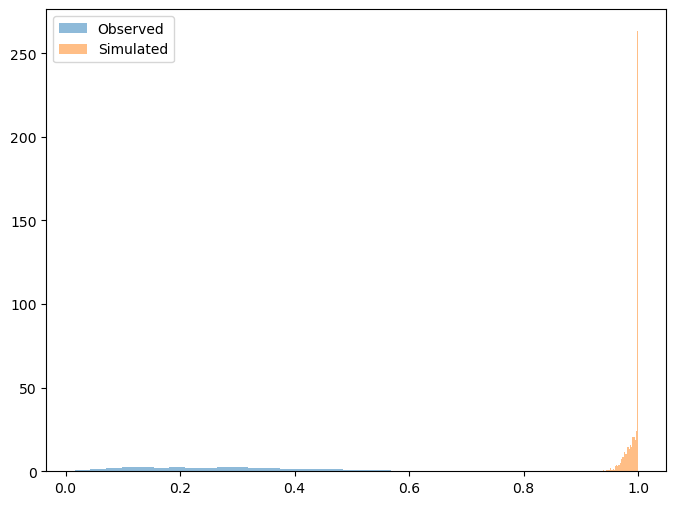

In [100]:
plt.figure(figsize=(8,6))

plt.hist(
    observed,
    bins=30,
    density=True,
    alpha=0.5,
    label="Observed"
)

plt.hist(
    simulated,
    bins=30,
    density=True,
    alpha=0.5,
    label="Simulated"
)

plt.legend()

plt.show()

Observed normal distribution, simulated one tail distribution. 

Female preference
+
positive feedback  too strong. 

genotype–phenotype–mate-choice feedback alone is insufficient to maintain alternative reproductive strategies.

## Future improuvement
1. negative frequency dependence
2. condition-dependent tactics
3. resource competition
4. density dependence

<!--  If long tail:  In this system:

Most males: low exhibition
Few males: high exhibition

Which means：
- sneaker males
- satellite males
- dominant males

A classical alternative reproductive strategy.  -->